# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()


Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print(df.isnull().mean()*100)
# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
not_leaky = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']      # điền danh sách cột khon cần bỏ (chỉ những cột có trong df)
#df = df.drop(columns=[])
print(df.columns)
leaky = [x for x in df.columns if x not in not_leaky]
df = df.drop(columns=leaky)
# print("Các cột còn lại:", list(df.columns))

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Alive gây rò rỉ dữ liệu bởi vì nếu đưa cột alive vào thì mô hình thay vì học cách dự đoán thì sẽ sử dụng giá trị của cột alive để đưa ra kết quả.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print('Số dòng:', df.shape[0])
print('Số cột:', df.shape[1])
print('Biến mục tiêu: Survived')
df.info()
print('Biến số')
print(df.describe().T)
print('Biến phân loại')
print(df.describe(include = ['object', 'category']))

Số dòng: 891
Số cột: 8
Biến mục tiêu: Survived
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
Biến số
          count       mean        std   min      25%      50%   75%       max
survived  891.0   0.383838   0.486592  0.00   0.0000   0.0000   1.0    1.0000
pclass    891.0   2.308642   0.836071  1.00   2.0000   3.0000   3.0    3.0000
age       714.0  29.699118  14.526497  0.42  20.1250  28.0000  38.0   80.0000
sibsp     891.0   0.523008   1.102743  0.00   0.0000   0.0000   1.0    8.0000
parch     891

C:\Users\hangh\AppData\Local\Temp\ipykernel_21880\3833509034.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include = ['object', 'category']))


**Trả lời 2 (biến số vs biến phân loại):**

Biến số: age, sibsp, parch, fare

Biến phân loại: survived, pclass, sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

          Missing Count  Missing Percentage
age                 177           19.865320
embarked              2            0.224467


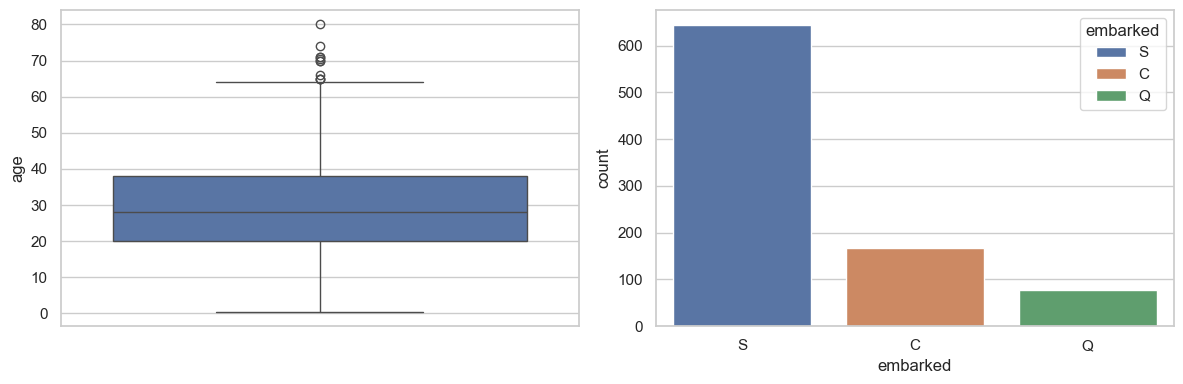

In [5]:
# TODO 3: bảng missing (count + %)
...
missing_percent = df.isnull().mean()*100
missing_count = df.isnull().sum()

missing_report = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage' : missing_percent})
print(missing_report[missing_report['Missing Count'] > 0])
fig, axes = plt.subplots(1,2,figsize = (12,4))
sns.boxplot(df['age'].dropna(), ax = axes[0],)
sns.countplot(df,x = 'embarked', ax = axes[1], hue = 'embarked')
plt.tight_layout()
plt.show()

**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|------|---------:|--------------------|--------|
|Age|20%|Điền median|Do xuất hiện nhiều outlier dẫn tới age có xu hướng lệch phải từ đó kéo mean tăng lên, median thường không bị ảnh hưởng bởi outlier nên fill missing value bằng median|
| Embarked | 0.2| Điền mode | Do số lượng missing value ít |


---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'


def dem_outlier_iqr(s):
    ...    # trả về số lượng outlier theo IQR
    x = df[s].dropna()
    q1, q3 = np.percentile(x,[25,75])
    iqr = q3-q1
    print(f'IQR of {s}:\nQ1: {q1}, Q3: {q3}, IQR: {iqr}')
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    mask = (x < lower) | (x > upper)
    return mask.sum()
print(dem_outlier_iqr('age'))
def dem_outlier_zscore(s, nguong=3.0):
    ...    # trả về số lượng outlier theo Z-score
    x = df[s].dropna()
    mean = x.mean()
    std = x.std()
    z_score = (x-mean)/std
    mask = np.abs(z_score) > nguong
    return mask.sum()

for col in ["age", "fare"]:
    print(f'Outlier for {col} theo iqr: ', dem_outlier_iqr(col))
    print(f'Outlier for {col} theo zscore: ', dem_outlier_zscore(col))

IQR of age:
Q1: 20.125, Q3: 38.0, IQR: 17.875
11
IQR of age:
Q1: 20.125, Q3: 38.0, IQR: 17.875
Outlier for age theo iqr:  11
Outlier for age theo zscore:  2
IQR of fare:
Q1: 7.9104, Q3: 31.0, IQR: 23.0896
Outlier for fare theo iqr:  116
Outlier for fare theo zscore:  20


**Trả lời 4 (quyết định với outlier của `fare`):**

Giữ nguyên fare vì fare phản ảnh giá vé và phản ánh đúng thực tế, một số khách hàng ở plcass cao sẽ phải trả giá tiền lớn hơn.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

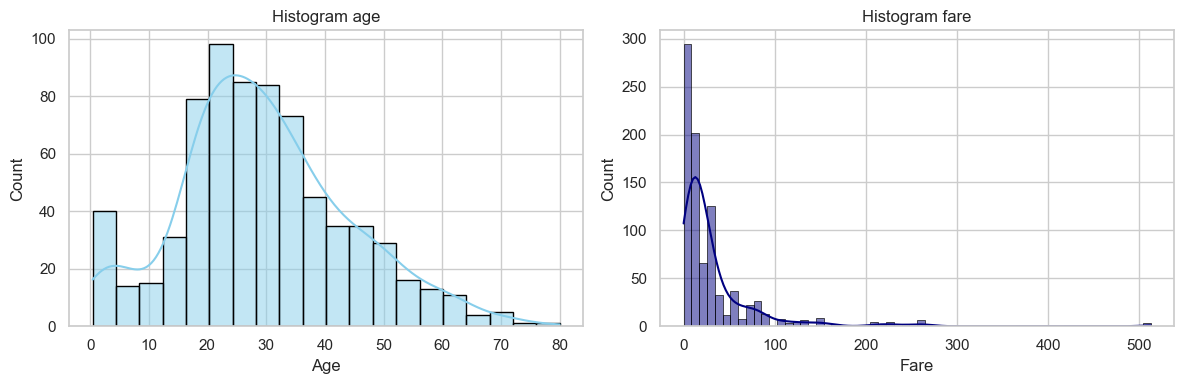

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1,2,figsize = (12,4))
sns.histplot(df['age'], color= 'skyblue', edgecolor = 'black', kde = True, ax=axes[0])
axes[0].set_title('Histogram age')
axes[0].set_xlabel('Age')

sns.histplot(df['fare'], ax=axes[1], color='navy', edgecolor = 'black', kde=True)
axes[1].set_title('Histogram fare')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

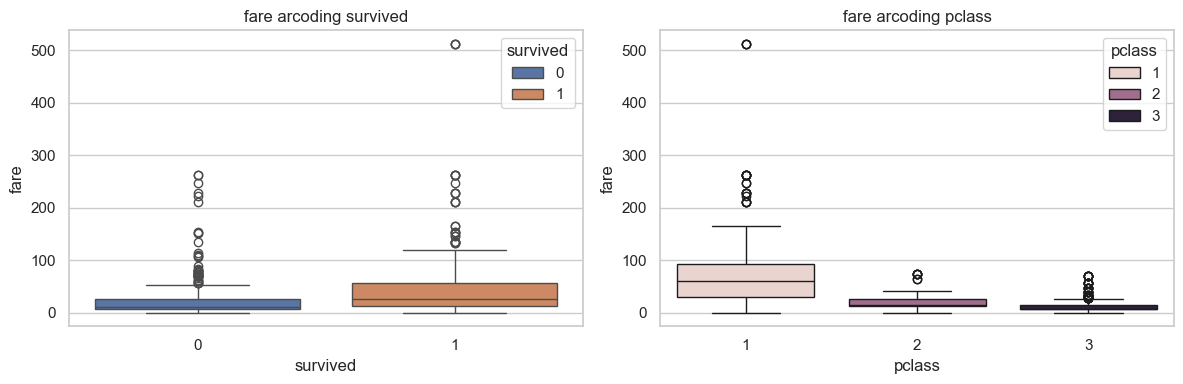

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
...
fig, axes = plt.subplots(1,2,figsize = (12,4))
sns.boxplot(df, x=df['survived'], y = df['fare'], hue='survived',ax=axes[0])
axes[0].set_title('fare arcoding survived')

sns.boxplot(df, x = df['pclass'], y = df['fare'], hue='pclass', ax = axes[1])
axes[1].set_title('fare arcoding pclass')

plt.tight_layout()
plt.show()

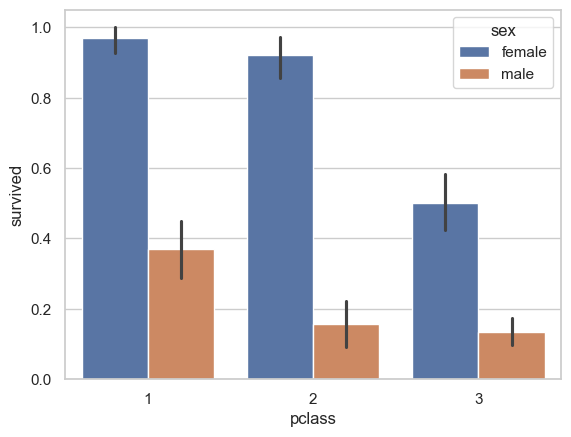

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
...
sns.barplot(df, x = 'pclass', y = 'survived', hue='sex')
plt.show()


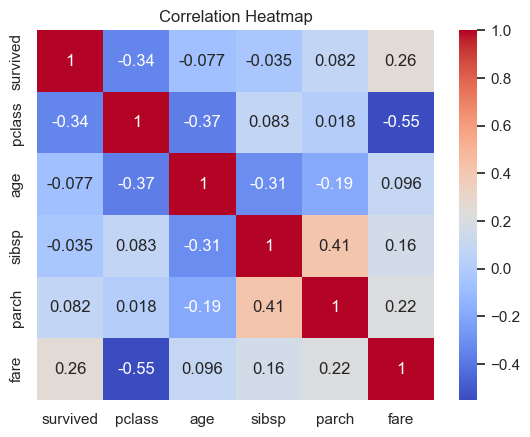

In [10]:
# TODO 5d: Heatmap correlation
...
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Biểu đồ Hitstogram của age và fare đều có xu hướng lệch phải, fare có outlier đặc biệt lớn.
- Boxplot:
Đối với fare theo survived thì những người sống sót có median cao hơn, cả 2 label đều có khá nhiều outlier.
- Bar survival: Tỷ lệ sống sót của nữ so với nam theo từng pclass bao giờ cũng cao hơn, những người có hạng vé càng cao cấp thì tỷ lệ sống sót càng cao.
- Heatmap: Biểu đồ heatmap cho thấy không có sự tương quan cao giữa các các biến, chưa xảy ra hiện tượng đa cộng tuyến nghiêm trọng giữa các biến.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns = 'survived')
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X,y, test_size=0.15, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size = 0.1765, stratify = y_tmp)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
#in tỷ lệ survived từng tập
print("Train/Val/Test (Survive):", y_train.mean()*100, y_val.mean()*100, y_test.mean()*100)

Train/Val/Test: (623, 7) (134, 7) (134, 7)
Train/Val/Test (Survive): 38.362760834670944 38.80597014925373 38.059701492537314


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy = 'most_frequent')),
    ("onehot",  OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
# ... transform cho val, test
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Vì khi fit các bộ tiền xử lý sẽ học được các thông số như mean, median, std, iqr..., nếu ta fit trên cả tập val, lẫn tập test thì mô hình sẽ học được các thông số từ tập val và tập test dẫn đến kết quả thiếu tính chính xác và không phản ánh đúng tính chính xác của mô hình.

## HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION

In [13]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_t, y_train)
y_pred_lr = lr_model.predict(X_test_t)
print ("Logistic Model")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report (Accuracy, Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred_lr))

Logistic Model

Confusion Matrix:
[[71 12]
 [19 32]]

Classification Report (Accuracy, Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        83
           1       0.73      0.63      0.67        51

    accuracy                           0.77       134
   macro avg       0.76      0.74      0.75       134
weighted avg       0.77      0.77      0.76       134



## HUẤN LUYỆN MÔ HÌNH LINEAR REGRESSION

In [14]:
linear_model = LinearRegression()
linear_model.fit(X_train_t, y_train)
y_pred_continuous = linear_model.predict(X_test_t)
y_pred_linear = (y_pred_continuous >= 0.5).astype(int)

print('Linear Model')
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

print("\nClassification Report (Accuracy, Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred_linear))

Linear Model

Confusion Matrix:
[[72 11]
 [19 32]]

Classification Report (Accuracy, Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        83
           1       0.74      0.63      0.68        51

    accuracy                           0.78       134
   macro avg       0.77      0.75      0.75       134
weighted avg       0.77      0.78      0.77       134



## Nhận xét
Cả hai mô hình đều cho kết quả phân loại tương đối tốt trên tập dữ liệu Titanic với Accuracy đạt $77\% - 78\%$.

Sự khác biệt giữa hai mô hình là không đáng kể. Cả hai đều đạt Precision và Recall rất cao ở lớp $0$ (Thiệt mạng) với F1-score $\approx 0.83$, nhưng lại gặp khó khăn hơn ở lớp $1$ (Sống sót) khi F1-score chỉ đạt quanh mức $0.67 - 0.68$. Điều này xảy ra do mô hình bị bỏ sót khá nhiều ca sống sót thực tế ($19$ ca FN trên tổng số $51$ ca thực tế).

Mặc dù Linear Model nhỉnh hơn $1\%$ về mặt số liệu thực nghiệm trên tập Test này, mô hình Logistic Regression (Logistic Model) vẫn là mô hình phù hợp và tối ưu hơn để giải quyết bài toán phân loại hành khách sống sót